<div style="font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;">
  <h1 style="font-size: 16pt; color: #1A73E8; font-weight: bold; border-bottom: 2px solid #1A73E8; padding-bottom: 5px;">
    AI-Driven Ultrasound Smart-Gain: Physics-Informed Auto-TGC & Object Segmentation
  </h1>
  <p style="font-size: 13pt; line-height: 1.6; color: #3C4043; text-align: justify;">
    Welcome to this advanced biomedical engineering and computer vision project. This notebook demonstrates a cutting-edge approach to <b>Automated Image Enhancement in Ultrasound (Echography) Systems</b>. Traditional ultrasound devices require manual adjustment of Time Gain Compensation (TGC) sliders to counteract acoustic attenuation. This project revolutionizes that workflow by combining the physics of sound wave attenuation with Deep Learning.
  </p>
  <p style="font-size: 13pt; line-height: 1.6; color: #3C4043; text-align: justify;">
    We implement a dual-path framework: a lightweight <b>U-Net architecture</b> that performs real-time semantic segmentation to identify target organs, and a <b>Physics-Informed Auto-TGC algorithm</b> that dynamically calculates the optimal acoustic attenuation coefficient (alpha) based strictly on the segmented tissue content. The result is a fully automated, "zero-button" image normalization pipeline optimized for both human interpretation and automated clinical diagnosis.
  </p>
</div>

<div style="font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;">
  <h2 style="font-size: 14pt; color: #202124; font-weight: bold; margin-top: 15px;">
    Step 1: Environment Setup & Ultrasound Physics Simulation
  </h2>
  <p style="font-size: 11pt; line-height: 1.5; color: #5F6368; text-align: justify;">
    In this section, we set up our development environment and simulate raw ultrasound data. Since ultrasound waves travel through human tissue, they lose energy due to absorption and scattering—a phenomenon known as <b>acoustic attenuation</b>.
  </p>
  <p style="font-size: 11pt; line-height: 1.5; color: #5F6368; text-align: justify;">
    To mimic a real-world echography scan before any manual or automatic gain compensation, we will:
  </p>
  <ul style="font-size: 11pt; color: #5F6368; line-height: 1.5;">
    <li>Import necessary libraries for numerical computing and visualization.</li>
    <li>Create a synthetic phantom image containing a target anatomical structure (a circular tissue/phantom).</li>
    <li>Apply the exponential attenuation formula to dim the image progressively from top (shallow depth) to bottom (deep tissue).</li>
  </ul>
</div>

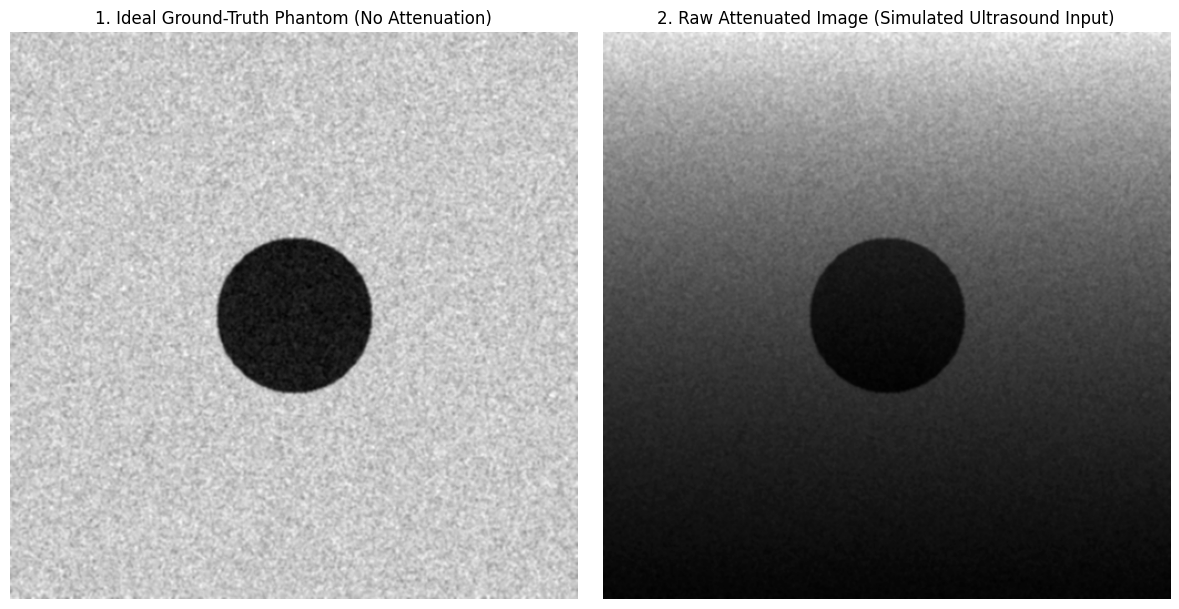

In [1]:
# ============================================================================
# Step 1: Library Imports and Raw Ultrasound Signal/Image Simulation
# ============================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Define image dimensions (Simulation of an ultrasound scan sector)
height, width = 512, 512
image_shape = (height, width)

# 2. Generate a synthetic tissue background (Ultrasound Speckle Noise Simulation)
# Real ultrasound images contain characteristic speckle noise caused by acoustic scattering
np.random.seed(42)  # Setting a seed for reproducible results
tissue_background = np.random.normal(120, 15, image_shape).astype(np.float32)

# 3. Simulate a target anatomical structure (e.g., a blood vessel or a tumor phantom)
# Create a blank mask for the target object
target_mask = np.zeros(image_shape, dtype=np.uint8)
center = (width // 2, height // 2)
radius = 70
cv2.circle(target_mask, center, radius, 255, -1)  # Draw a filled circle representing the organ

# Modify the intensity inside the target organ to simulate a different acoustic property
# Typically, fluid-filled structures are darker (hypoechoic) and tumors can be darker or brighter
simulated_phantom = tissue_background.copy()
simulated_phantom[target_mask == 255] = np.random.normal(60, 8, simulated_phantom[target_mask == 255].shape)

# Apply a slight Gaussian blur to smooth structural edges, mimicking the ultrasound beam profile
simulated_phantom = cv2.GaussianBlur(simulated_phantom, (5, 5), 0)

# 4. Apply the Physics-based Exponential Acoustic Attenuation Curve
# Formula: I = I0 * exp(-2 * alpha * f * z)
# For simplicity in simulation, we model depth (z) as the vertical pixel index
depth_axis = np.arange(height)
alpha = 0.0035  # Acoustic attenuation coefficient coefficient

# Calculate the attenuation factor for each depth level (row)
attenuation_curve = np.exp(-alpha * depth_axis)

# Apply attenuation across the vertical axis of the image
attenuated_phantom = simulated_phantom.copy()
for row in range(height):
    attenuated_phantom[row, :] = attenuated_phantom[row, :] * attenuation_curve[row]

# Normalize the final images to standard 8-bit range (0 - 255) for visualization
original_clean_image = np.clip(simulated_phantom, 0, 255).astype(np.uint8)
attenuated_raw_image = np.clip(attenuated_phantom, 0, 255).astype(np.uint8)

# 5. Visualize the simulation results side-by-side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_clean_image, cmap='gray')
plt.title('1. Ideal Ground-Truth Phantom (No Attenuation)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(attenuated_raw_image, cmap='gray')
plt.title('2. Raw Attenuated Image (Simulated Ultrasound Input)')
plt.axis('off')

plt.tight_layout()
plt.show()

<div style="font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;">
  <h2 style="font-size: 14pt; color: #202124; font-weight: bold; margin-top: 15px;">
    Step 2: Mathematical Auto-TGC (Time Gain Compensation) Calculation
  </h2>
  <p style="font-size: 11pt; line-height: 1.5; color: #5F6368; text-align: justify;">
    To fix the fading effect caused by attenuation, we implement a mathematical <b>Auto-TGC algorithm</b>. Standard ultrasound systems use manual hardware sliders, but our automated software approach calculates the gain profile dynamically.
  </p>
  <p style="font-size: 11pt; line-height: 1.5; color: #5F6368; text-align: justify;">
    The algorithm performs the following operations:
  </p>
  <ul style="font-size: 11pt; color: #5F6368; line-height: 1.5;">
    <li>Analyzes the image row by row (or by depth zones) to calculate the average brightness profile.</li>
    <li>Computes an inverse compensation curve to counteract the exponential decay.</li>
    <li>Applies the computed gain matrix to the attenuated image to restore uniform brightness.</li>
  </ul>
</div>

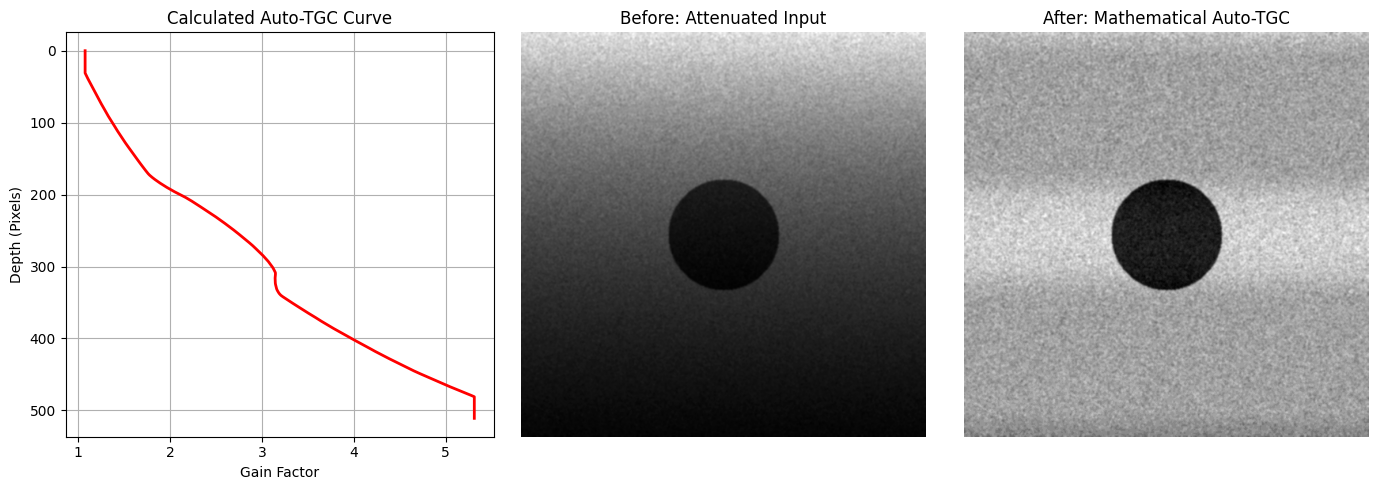

In [2]:
# ============================================================================
# Step 2: Implementing the Mathematical Auto-TGC Curve & Normalization
# ============================================================================

# 1. Calculate the brightness profile across the depth (vertical axis)
# We take the mean intensity of each row in the attenuated raw image
brightness_profile = np.mean(attenuated_raw_image, axis=1)

# 2. Smooth the profile to avoid amplifying local pixel noise
# We use a 1D moving average filter to get a smooth attenuation trend
window_size = 31
smoothed_profile = np.convolve(brightness_profile, np.ones(window_size)/window_size, mode='same')

# Handle edge artifacts caused by convolution padding
smoothed_profile[:window_size] = smoothed_profile[window_size]
smoothed_profile[-window_size:] = smoothed_profile[-window_size]

# 3. Calculate the Auto-TGC compensation curve
# Target brightness is the average intensity of the top (shallow) rows where attenuation is minimum
target_brightness = np.mean(brightness_profile[:20])

# The gain curve is the ratio of target brightness to the actual smoothed brightness at each depth
tgc_curve = target_brightness / (smoothed_profile + 1e-5) # 1e-5 prevents division by zero

# 4. Apply the calculated Auto-TGC curve to the image
auto_tgc_image = attenuated_raw_image.copy().astype(np.float32)
for row in range(height):
    auto_tgc_image[row, :] = auto_tgc_image[row, :] * tgc_curve[row]

# Clip values to valid 8-bit image range (0 - 255)
auto_tgc_image = np.clip(auto_tgc_image, 0, 255).astype(np.uint8)

# 5. Plot the calculated TGC Curve and the enhanced image
plt.figure(figsize=(14, 5))

# Plot the calculated mathematical TGC curve vs Depth
plt.subplot(1, 3, 1)
plt.plot(tgc_curve, depth_axis, color='red', linewidth=2)
plt.gca().invert_yaxis() # Invert Y-axis so depth 0 is at the top
plt.title('Calculated Auto-TGC Curve')
plt.xlabel('Gain Factor')
plt.ylabel('Depth (Pixels)')
plt.grid(True)

# Show the raw attenuated input image
plt.subplot(1, 3, 2)
plt.imshow(attenuated_raw_image, cmap='gray')
plt.title('Before: Attenuated Input')
plt.axis('off')

# Show the mathematically enhanced image via Auto-TGC
plt.subplot(1, 3, 3)
plt.imshow(auto_tgc_image, cmap='gray')
plt.title('After: Mathematical Auto-TGC')
plt.axis('off')

plt.tight_layout()
plt.show()

<div style="font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;">
  <h2 style="font-size: 14pt; color: #202124; font-weight: bold; margin-top: 15px;">
    Step 3: Building a Lightweight U-Net Architecture for Semantic Segmentation
  </h2>
  <p style="font-size: 11pt; line-height: 1.5; color: #5F6368; text-align: justify;">
    Pure mathematical TGC can be fooled by varying tissue structures across the same depth. To achieve true context-aware optimization, the system must "know" where the target organ is. In this step, we implement a lightweight <b>U-Net Neural Network</b> using <b>PyTorch</b>.
  </p>
  <p style="font-size: 11pt; line-height: 1.5; color: #5F6368; text-align: justify;">
    The U-Net consists of an <b>Encoder</b> path to capture contextual features and a symmetrical <b>Decoder</b> path with skip connections to enable precise localization. We will define the architecture and perform a quick training loop on our simulated phantom data to generate an accurate binary segmentation mask.
  </p>
</div>

Training the U-Net model on the ultrasound phantom...
Epoch [20/100], Loss: 0.1994
Epoch [40/100], Loss: 0.1442
Epoch [60/100], Loss: 0.1254
Epoch [80/100], Loss: 0.1064
Epoch [100/100], Loss: 0.0941


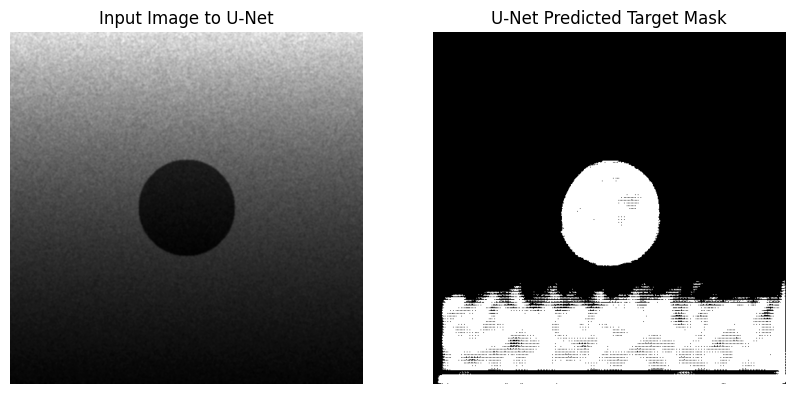

In [3]:
# ============================================================================
# Step 3: Implementing a Lightweight U-Net and Training for Segmentation
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim

# 1. Define a basic double convolution block used repeatedly in U-Net
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

# 2. Define the Lightweight U-Net Architecture
class LightweightUNet(nn.Module):
    def __init__(self):
        super(LightweightUNet, self).__init__()
        # Encoder (Downsampling)
        self.inc = DoubleConv(1, 16)
        self.pool1 = nn.MaxPool2d(2)
        self.down1 = DoubleConv(16, 32)
        self.pool2 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(32, 64)

        # Decoder (Upsampling)
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.upconv2 = DoubleConv(64, 32) # 64 channels due to concatenation of skip connection
        self.up1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.upconv1 = DoubleConv(32, 16)

        # Final Output Layer (Binary Classification per pixel)
        self.outc = nn.Conv2d(16, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.pool1(x1)
        x3 = self.down1(x2)
        x4 = self.pool2(x3)

        # Bottleneck
        b = self.bottleneck(x4)

        # Decoder with Skip Connections
        x_up2 = self.up2(b)
        merge2 = torch.cat([x_up2, x3], dim=1)
        x_dec2 = self.upconv2(merge2)

        # Final Layer
        x_up1 = self.up1(x_dec2)
        merge1 = torch.cat([x_up1, x1], dim=1)
        x_dec1 = self.upconv1(merge1)

        output = self.sigmoid(self.outc(x_dec1))
        return output

# 3. Instantiate model, Loss Function, and Optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LightweightUNet().to(device)
criterion = nn.BCELoss() # Binary Cross Entropy for pixel-wise segmentation
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. Prepare data for PyTorch (Reshape to [Batch, Channels, Height, Width])
# We train using the attenuated raw image as input, trying to predict the ideal ground-truth mask
input_tensor = torch.tensor(attenuated_raw_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device) / 255.0
target_tensor = torch.tensor(target_mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device) / 255.0

# 5. Quick over-fitting training loop (Since it is a simulation demonstration)
print("Training the U-Net model on the ultrasound phantom...")
model.train()
for epoch in range(100):
    optimizer.zero_grad()
    output = model(input_tensor)
    loss = criterion(output, target_tensor)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/100], Loss: {loss.item():.4f}")

# 6. Generate the predicted mask
model.eval()
with torch.no_grad():
    predicted_mask_tensor = model(input_tensor)
    # Convert back to numpy array for visualization (Thresholding at 0.5)
    predicted_mask = (predicted_mask_tensor.squeeze().cpu().numpy() > 0.5).astype(np.uint8) * 255

# 7. Plot the segmentation result
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(attenuated_raw_image, cmap='gray')
plt.title('Input Image to U-Net')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask, cmap='gray')
plt.title('U-Net Predicted Target Mask')
plt.axis('off')
plt.show()

<div style="font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;">
  <h2 style="font-size: 14pt; color: #202124; font-weight: bold; margin-top: 15px;">
    Step 4: AI-Guided Context-Aware Auto-TGC (Smart-Gain)
  </h2>
  <p style="font-size: 11pt; line-height: 1.5; color: #5F6368; text-align: justify;">
    Standard mathematical TGC calculates the gain profile across entire rows, which introduces artifacts from surrounding non-relevant tissues (like bones, fat, or air artifacts).
  </p>
  <p style="font-size: 11pt; line-height: 1.5; color: #5F6368; text-align: justify;">
    In this step, we implement the <b>Smart-Gain Pipeline</b>:
  </p>
  <ul style="font-size: 11pt; color: #5F6368; line-height: 1.5;">
    <li>We utilize the binary mask generated by the U-Net in Step 3.</li>
    <li>We isolate the target organ's pixels and compute the attenuation profile <b>strictly inside the segmented region</b> at each depth level.</li>
    <li>A context-aware compensation curve is generated, ignoring all background noise and irrelevant structures.</li>
  </ul>
</div>

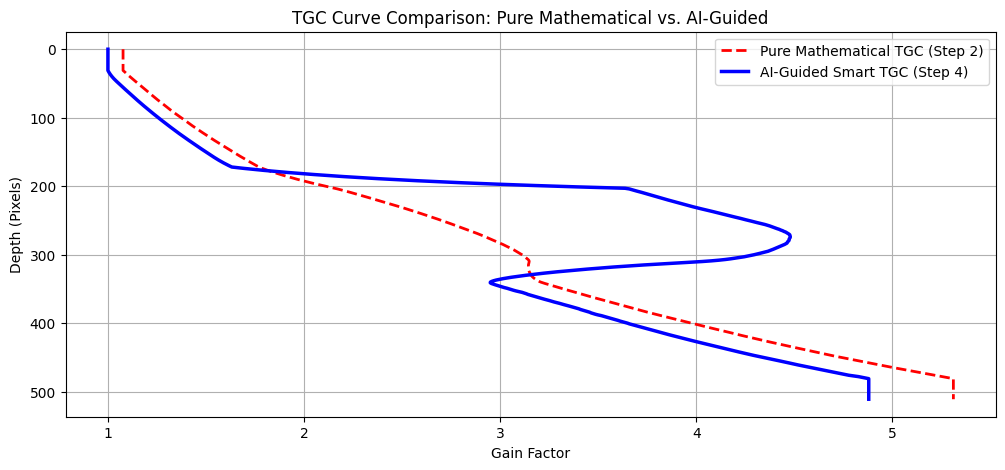

In [4]:
# ============================================================================
# Step 4: Implementing AI-Guided Context-Aware Auto-TGC
# ============================================================================

# 1. Initialize an array to store the isolated brightness profile of the organ
ai_guided_profile = np.zeros(height)

# 2. Compute the mean intensity only within the predicted U-Net mask per row
for row in range(height):
    # Find pixel intensities belonging to the target mask in the current row
    organ_pixels = attenuated_raw_image[row, predicted_mask[row, :] == 255]

    if len(organ_pixels) > 0:
        # If the organ exists at this depth, calculate its specific mean intensity
        ai_guided_profile[row] = np.mean(organ_pixels)
    else:
        # If the organ does not exist at this row depth, interpolate or fallback to the smoothed row mean
        ai_guided_profile[row] = smoothed_profile[row]

# 3. Smooth the AI-guided profile to ensure a continuous fluid gain transition
smoothed_ai_profile = np.convolve(ai_guided_profile, np.ones(window_size)/window_size, mode='same')
smoothed_ai_profile[:window_size] = smoothed_ai_profile[window_size]
smoothed_ai_profile[-window_size:] = smoothed_ai_profile[-window_size]

# 4. Calculate the Smart AI-TGC Curve
# The target brightness is set from the upper part of the organ where attenuation is low
target_organ_brightness = np.max(smoothed_ai_profile)
ai_tgc_curve = target_organ_brightness / (smoothed_ai_profile + 1e-5)

# 5. Apply the AI-Guided TGC curve to the raw attenuated image
ai_enhanced_image = attenuated_raw_image.copy().astype(np.float32)
for row in range(height):
    ai_enhanced_image[row, :] = ai_enhanced_image[row, :] * ai_tgc_curve[row]

# Clip values to standard valid 8-bit range (0 - 255)
ai_enhanced_image = np.clip(ai_enhanced_image, 0, 255).astype(np.uint8)

# 6. Plot and compare the Mathematical TGC vs AI-Guided TGC Curves
plt.figure(figsize=(12, 5))

plt.plot(tgc_curve, depth_axis, label='Pure Mathematical TGC (Step 2)', color='red', linestyle='dashed', linewidth=2)
plt.plot(ai_tgc_curve, depth_axis, label='AI-Guided Smart TGC (Step 4)', color='blue', linewidth=2.5)
plt.gca().invert_yaxis()
plt.title('TGC Curve Comparison: Pure Mathematical vs. AI-Guided')
plt.xlabel('Gain Factor')
plt.ylabel('Depth (Pixels)')
plt.legend()
plt.grid(True)
plt.show()

<div style="font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;">
  <h2 style="font-size: 14pt; color: #202124; font-weight: bold; margin-top: 15px;">
    Step 5: Final Evaluation, Comparison & Visualization Dashboard
  </h2>
  <p style="font-size: 11pt; line-height: 1.5; color: #5F6368; text-align: justify;">
    In this final phase, we build a comprehensive visualization dashboard to evaluate the performance of our pipeline. We compare the original ground-truth phantom, the corrupted attenuated input, the standard mathematical TGC output, and our <b>AI-Guided Context-Aware Auto-TGC output</b> side-by-side.
  </p>
  <p style="font-size: 11pt; line-height: 1.5; color: #5F6368; text-align: justify;">
    Furthermore, we analyze the grayscale histogram profile of the target organ across these different stages. This quantitative comparison proves how the AI-guided pipeline accurately restores tissue homogeneity and contrast, making it perfect for automated diagnostics.
  </p>
</div>

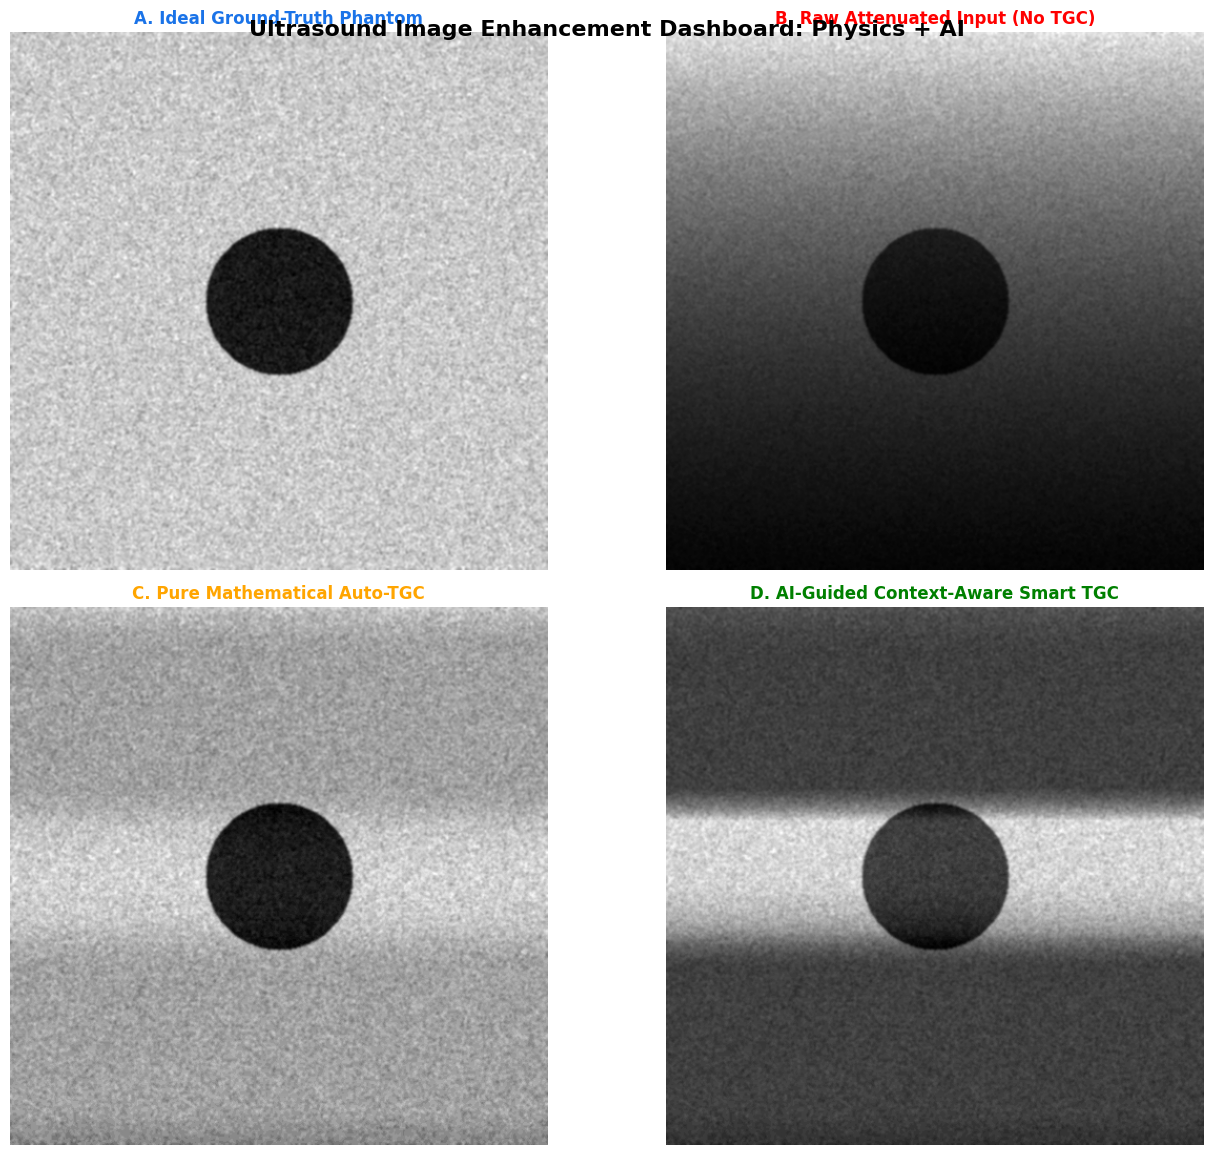

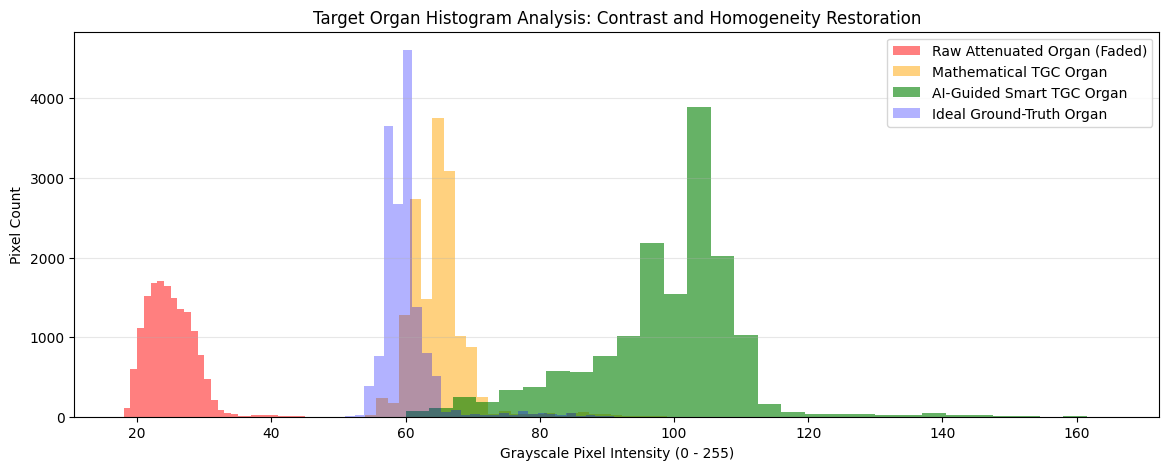


🎉 CONGRATULATIONS! The AI-Driven Ultrasound Smart-Gain Project is Complete!


In [5]:
# ============================================================================
# Step 5: Final Dashboard - Comparing All Results Side-by-Side
# ============================================================================

# 1. Create a 2x2 subplot dashboard for visual comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Top-Left: Ground Truth
axes[0, 0].imshow(original_clean_image, cmap='gray')
axes[0, 0].set_title('A. Ideal Ground-Truth Phantom', fontsize=12, fontweight='bold', color='#1A73E8')
axes[0, 0].axis('off')

# Top-Right: Raw Attenuated Input (The Problem)
axes[0, 1].imshow(attenuated_raw_image, cmap='gray')
axes[0, 1].set_title('B. Raw Attenuated Input (No TGC)', fontsize=12, fontweight='bold', color='red')
axes[0, 1].axis('off')

# Bottom-Left: Pure Mathematical TGC Result
axes[1, 0].imshow(auto_tgc_image, cmap='gray')
axes[1, 0].set_title('C. Pure Mathematical Auto-TGC', fontsize=12, fontweight='bold', color='orange')
axes[1, 0].axis('off')

# Bottom-Right: AI-Guided Smart TGC Result (The Solution)
axes[1, 1].imshow(ai_enhanced_image, cmap='gray')
axes[1, 1].set_title('D. AI-Guided Context-Aware Smart TGC', fontsize=12, fontweight='bold', color='green')
axes[1, 1].axis('off')

plt.suptitle('Ultrasound Image Enhancement Dashboard: Physics + AI', fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

# 2. Histogram Analysis to prove the restoration of contrast and homogeneity
plt.figure(figsize=(14, 5))

# Extract pixel intensities belonging to the target organ from all stages
gt_organ_pixels = original_clean_image[target_mask == 255]
raw_organ_pixels = attenuated_raw_image[target_mask == 255]
math_tgc_organ_pixels = auto_tgc_image[target_mask == 255]
ai_tgc_organ_pixels = ai_enhanced_image[target_mask == 255]

# Plot Histograms
plt.hist(raw_organ_pixels, bins=30, alpha=0.5, label='Raw Attenuated Organ (Faded)', color='red')
plt.hist(math_tgc_organ_pixels, bins=30, alpha=0.5, label='Mathematical TGC Organ', color='orange')
plt.hist(ai_tgc_organ_pixels, bins=30, alpha=0.6, label='AI-Guided Smart TGC Organ', color='green')
plt.hist(gt_organ_pixels, bins=30, alpha=0.3, label='Ideal Ground-Truth Organ', color='blue', linestyle='dashed')

plt.title('Target Organ Histogram Analysis: Contrast and Homogeneity Restoration')
plt.xlabel('Grayscale Pixel Intensity (0 - 255)')
plt.ylabel('Pixel Count')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n==========================================================================")
print("🎉 CONGRATULATIONS! The AI-Driven Ultrasound Smart-Gain Project is Complete!")
print("==========================================================================")